# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Rakha Makarim | 5054251010|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [33]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, roc_curve, roc_auc_score, confusion_matrix

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('/home/makarim/Desktop/Collage/Machine Learning/Task_ML/NB_LGR/Dataset/diabetes.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


/tmp/ipykernel_7424/1025743107.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='viridis')


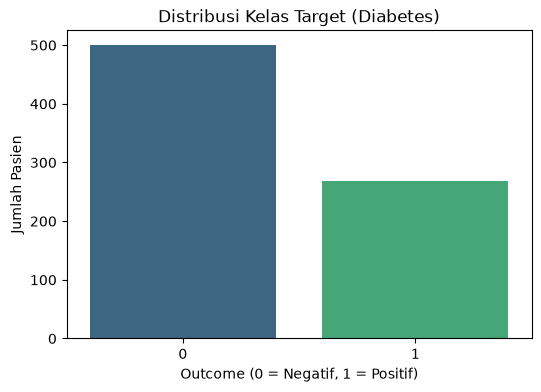

In [4]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', palette='viridis')
plt.title('Distribusi Kelas Target (Diabetes)')
plt.xlabel('Outcome (0 = Negatif, 1 = Positif)')
plt.ylabel('Jumlah Pasien')
plt.show()

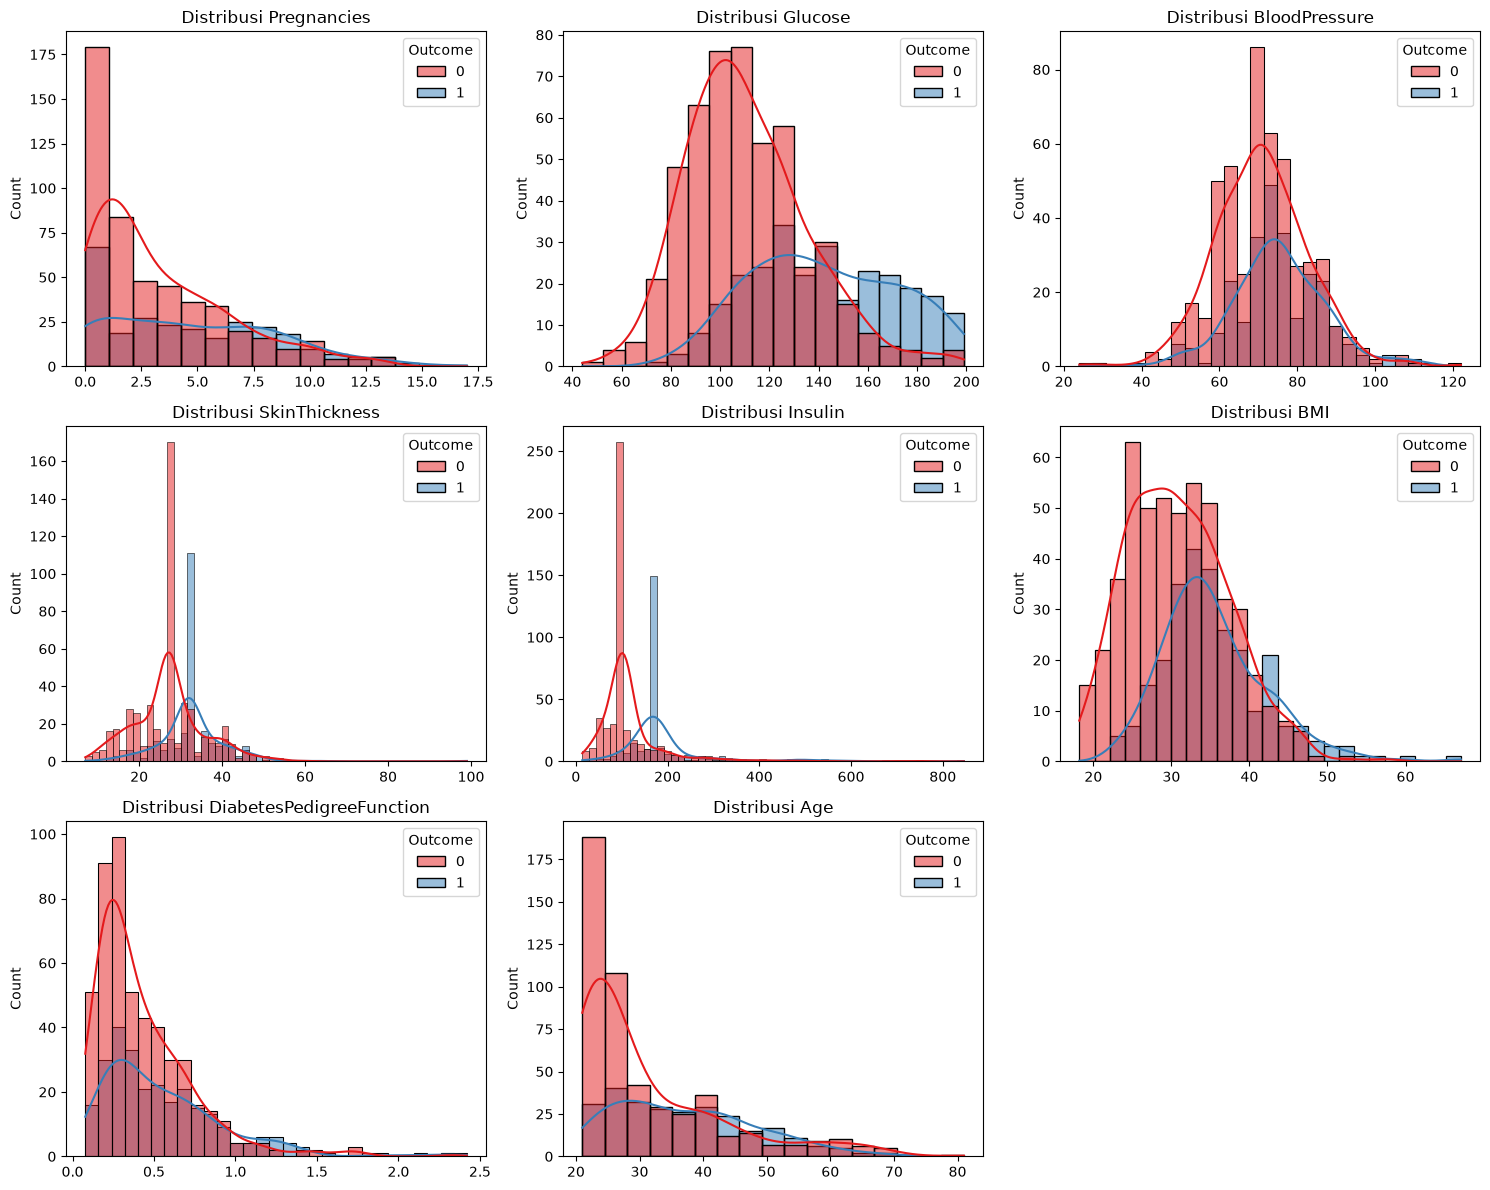

In [5]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = df.columns[:-1]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

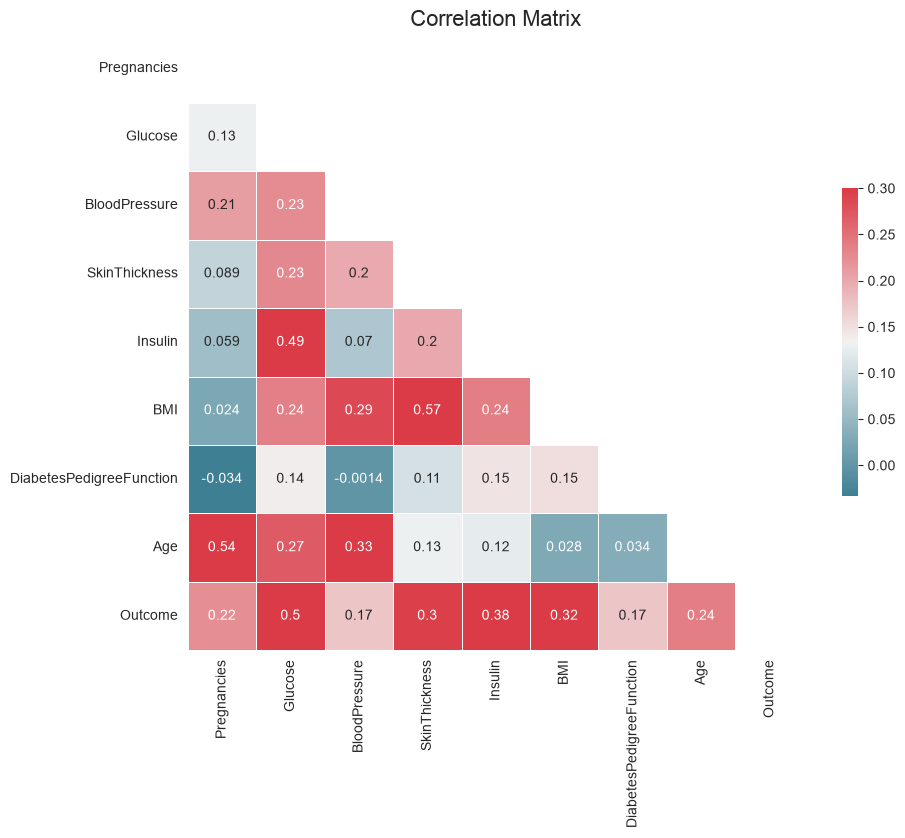

In [6]:
# Tampilkan heatmap korelasi antar fitur.
diabetes = df.corr()
mask = np.zeros_like(diabetes, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(220, 10, as_cmap=True)

with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(10, 8))
    ax = sns.heatmap(diabetes, cmap=cmap, mask=mask, vmax=.3, square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
    plt.title('Correlation Matrix', fontsize=16)
    plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

test_kolom = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_dt = (df[test_kolom] == 0).sum()
display(pd.DataFrame(zero_dt))

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_test_std = std.fit_transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [22]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb_model = GaussianNB()
gnb_model.fit(X_train_std, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [23]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_predGNB = gnb_model.predict(X_test_std)
y_probGNB = gnb_model.predict_proba(X_test_std)[:, 1]

## 3.2 Logistic Regression

In [26]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
LG_model = LogisticRegression()
LG_model.fit(X_train_std, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [31]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_predLG = LG_model.predict(X_test_std)
y_probLG = LG_model.predict_proba(X_test_std)[:, 1]

# 4. Evaluasi Model

In [32]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

md_GNB = get_metrics(y_test, y_predGNB)
md_LG = get_metrics(y_test, y_predLG)

df_eval = pd.DataFrame([md_GNB, md_LG], index=['Gaussian NB', 'LogisticRegression'])
display(df_eval)

,Accuracy,Precision,Recall,F1-Score
Gaussian NB,0.740260,0.629630,0.629630,0.629630
LogisticRegression,0.720779,0.617021,0.537037,0.574257


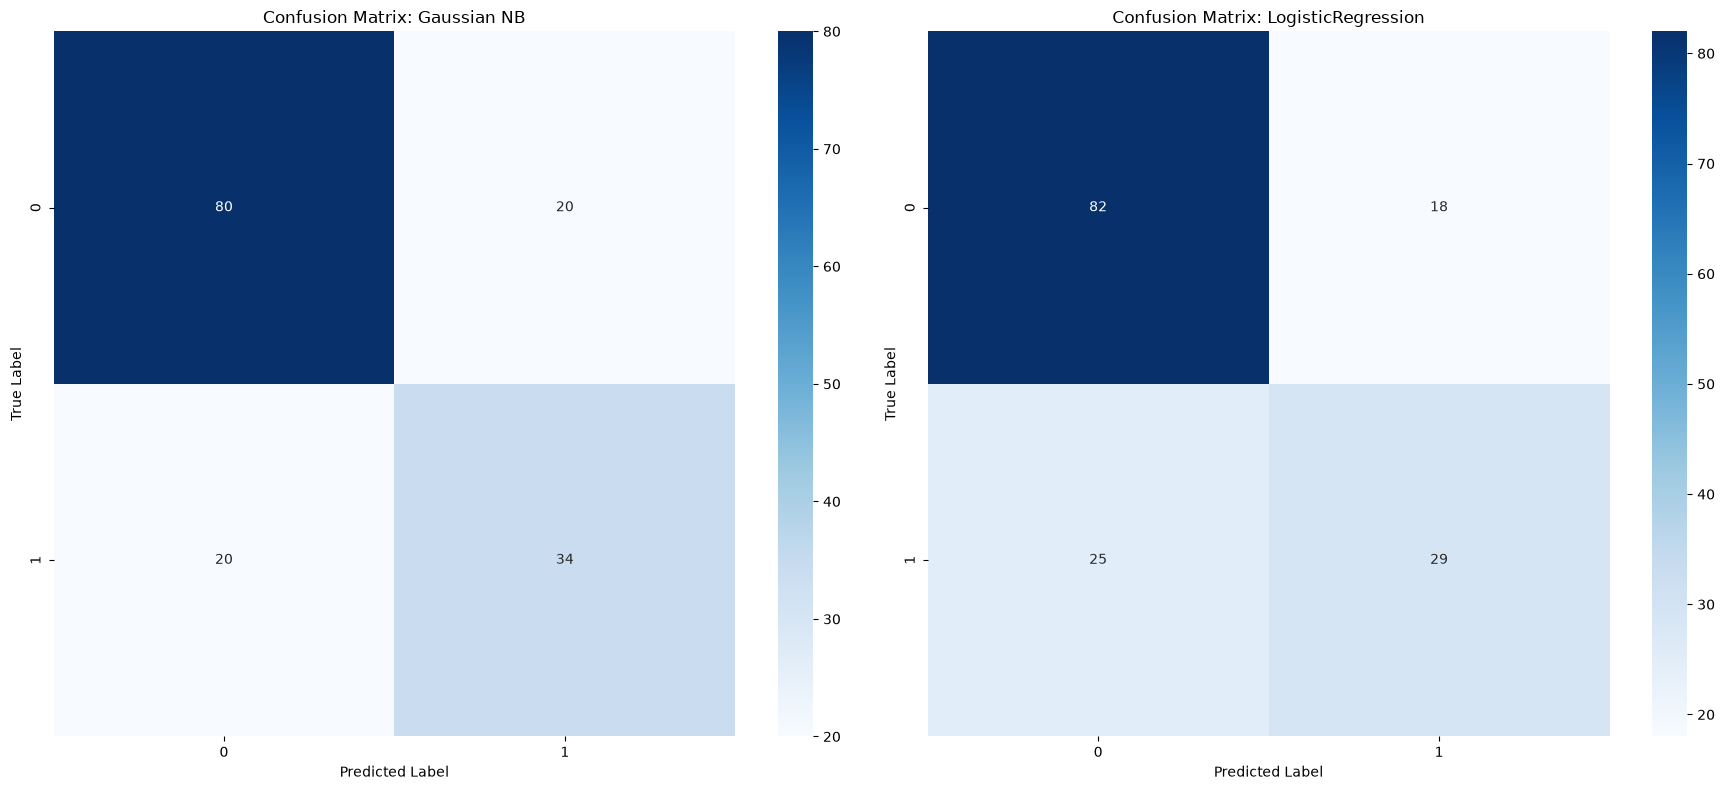

In [40]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
y_pred =[y_predGNB, y_predLG]
model_names = ['Gaussian NB', 'LogisticRegression']

for i, (pred, name) in enumerate(zip(y_pred, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

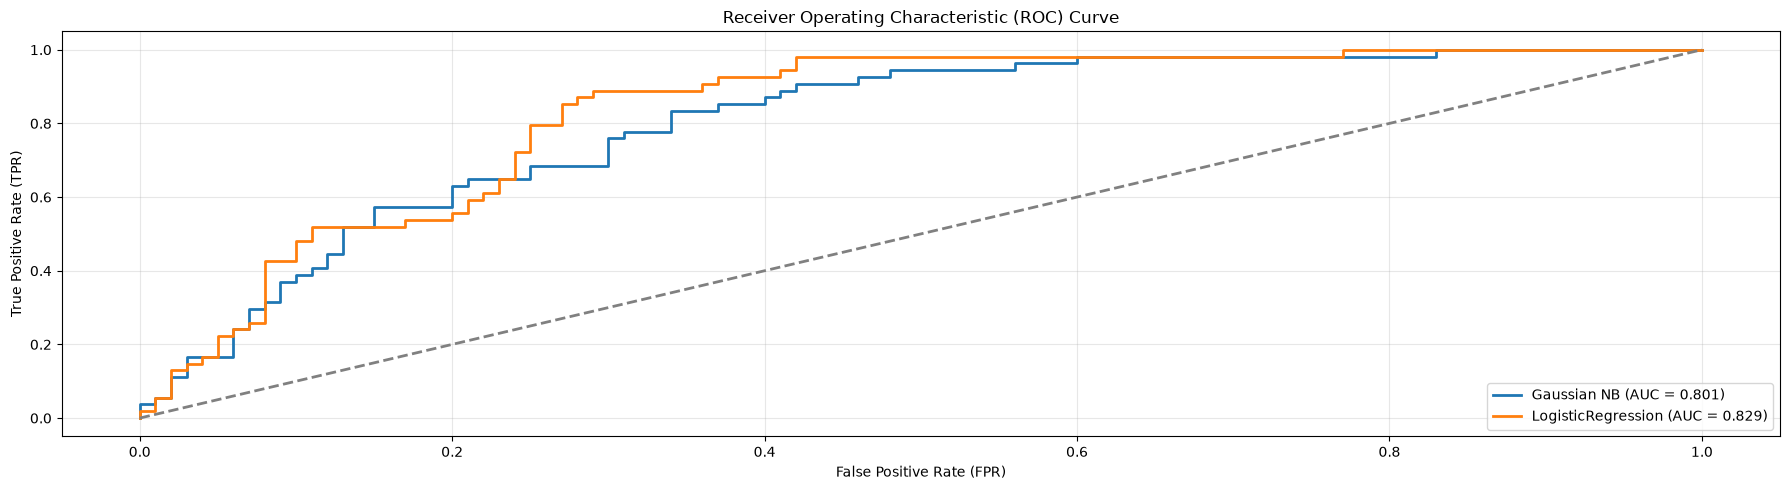

In [41]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fig, axes = plt.subplots(figsize=(18, 5))
y_prob  =[y_probGNB, y_probLG]
model_names = ['Gaussian NB', 'LogisticRegression']

for prob, name in zip(y_prob, model_names):
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

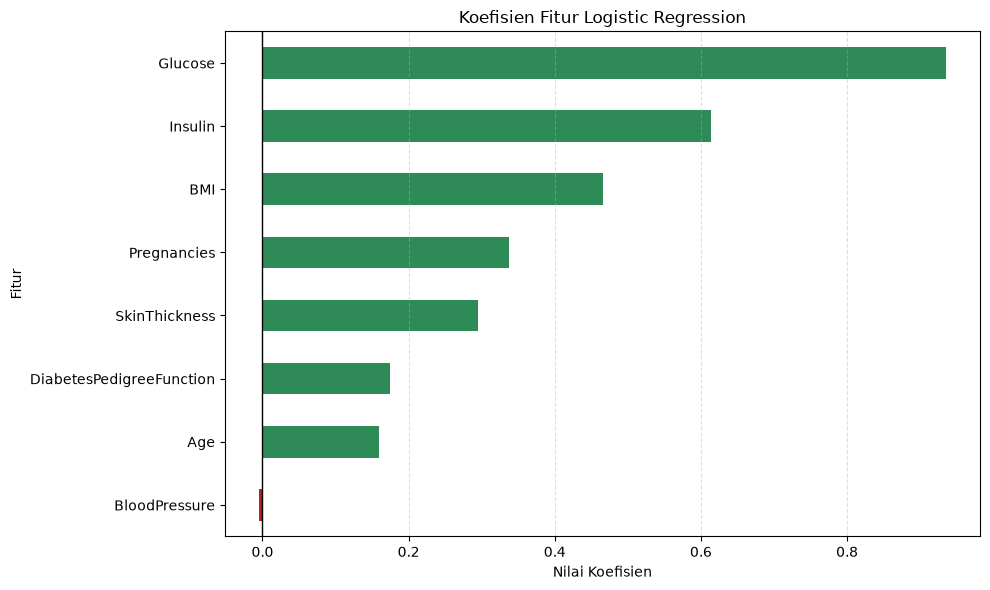

In [42]:
# Tampilkan koefisien Logistic Regression dalam bar chart horizontal.
# Koefisien positif meningkatkan log-odds diabetes, sedangkan negatif menurunkannya.

koefisien = pd.Series(
    LG_model.coef_[0],
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 6))
warna = ['firebrick' if nilai < 0 else 'seagreen' for nilai in koefisien]

koefisien.plot(kind='barh', color=warna)
plt.axvline(0, color='black', linewidth=1)
plt.title('Koefisien Fitur Logistic Regression')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Analisis

Hasil :

    1. GaussianNB unggul di accuracy (0.7403), recall (0.6296), dan f1 (0.6296) dibanding Logistic Regression (accuracy 0.7208, recall 0.5370, f1 0.5743) pada threshold default 0.5.
    2. Tapi AUC Logistic Regression justru lebih tinggi (0.829 vs 0.801) — artinya secara ranking probabilitas LogReg lebih baik bedain kelas, cuma kurang optimal pas dipotong di threshold 0.5.

- GaussianNB asumsi tiap fitur ngikutin distribusi normal per kelas, jadi kalau nilai fitur (misal Glucose) jauh dari rata-rata kelas negatif, probabilitas kelas positif langsung naik cukup drastis → lebih agresif nangkep kelas positif, makanya recall lebih tinggi.
- Logistic Regression lebih konservatif ke kelas negatif di threshold 0.5, FN lebih banyak (25 vs 20 punya GaussianNB), makanya recall & f1 kalah walau AUC-nya menang.
- Confusion matrix : GaussianNB = TN80/FP20/FN20/TP34, LogReg = TN82/FP18/FN25/TP29.
- Koefisien LogReg nunjukin Glucose paling dominan (positif), disusul Insulin dan BMI, sedangkan BloodPressure kontribusinya nyaris 0 — sejalan sama pengetahuan medis soal diabetes.

# 6. Kesimpulan dan Saran

Kesimpulan :

    1. Kedua model cukup efektif klasifikasi diabetes tapi belum optimal, accuracy cuma di kisaran 72-74%.
    2. GaussianNB lebih unggul kalau prioritasnya recall (nangkep pasien diabetes sebanyak mungkin), sedangkan Logistic Regression lebih unggul dari sisi ranking probabilitas (AUC) tapi kurang optimal di threshold default.

- Untuk kasus medis kayak gini, recall biasanya lebih penting dibanding precision karena FN (pasien diabetes yang keprediksi negatif) lebih beresiko dibanding FP. Jadi GaussianNB secara praktis lebih aman dipakai apa adanya.
- Tapi karena AUC LogReg lebih tinggi, threshold-nya bisa diturunin dari 0.5 (misal ke 0.3-0.4) buat naikin recall tanpa ganti model — worth dicoba di eksperimen selanjutnya.

Saran :
- Coba threshold tuning buat LogReg biar recall-nya bisa nyusul atau ngelewatin GaussianNB.
- Perbaiki bug di preprocessing (`X_test_std = std.fit_transform(X_test)` harusnya `std.transform(X_test)`), soalnya scaler beda antara train dan test bikin hasil kurang valid.
- Cek juga apakah butuh balancing kelas atau class_weight, ngingetin distribusi Outcome kemungkinan gak seimbang (700-an negatif vs 300-an positif).
- Bandingin sama model lain (Random Forest / SVM) buat liat apakah pola recall-vs-AUC ini konsisten atau karakteristik khusus dataset ini.